# MIMIC-III NLP Tutorial: spaCy vs scispaCy vs medspaCy
### Data Cohort: Subarachnoid Hemorrhage (ICD-9 430) — Discharge Summaries

This notebook demonstrates entity extraction, word2vec embeddings, and tuned t-SNE
visualizations using three NLP libraries applied to real MIMIC-III clinical notes:

1. **spaCy** — general-purpose NLP
2. **scispaCy** — biomedical-domain NLP
3. **medspaCy** — clinical NLP with context/negation detection



## 1. Setup & Installs

In [13]:

!pip install -q --upgrade pip
!pip install -q --upgrade "numpy>=2.0" "gensim>=4.4.0" "scikit-learn>=1.5" matplotlib seaborn


!pip install -q --upgrade spacy


!pip install -q --upgrade scispacy
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz


!pip install -q --upgrade medspacy

# spacy's small English model
!python -m spacy download en_core_web_sm -q



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.5.1 which is incompatible.
en-ner-bc5cdr-md 0.5.4 requires spacy<3.8.0,>=3.7.4, but you have spacy 3.8.14 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
en-ner-bc5cdr-md 0.5.4 requires spacy<3.8.0,>=3.7.4, but you have spacy 3.8.14 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-pytho

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import spacy
import scispacy
import medspacy
from medspacy.visualization import visualize_ent

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

pd.set_option('display.max_colwidth', 200)
np.random.seed(42)


## 2. Cohort Extraction (BigQuery)

We pull **discharge summaries** for patients diagnosed with **ICD-9 code 430**
(subarachnoid hemorrhage), following the same pattern used in prior assignments.


In [15]:
# ==========================================
# 2. DATA EXTRACTION & DATA CLEANING
# ==========================================
import pandas as pd
import numpy as np
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project='mc-ut-msai-aih-1') # Replace with assigned project ID

cohort_query = """
SELECT n.row_id, n.subject_id, n.hadm_id, n.text
FROM `physionet-data.mimiciii_notes.noteevents` n
JOIN (
    SELECT DISTINCT subject_id
    FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
    WHERE icd9_code = '430'
) sah ON n.subject_id = sah.subject_id
WHERE n.category = 'Discharge summary'
"""
df_notes = client.query(cohort_query).to_dataframe()

def clean_clinical_text(text):
    text = re.sub(r'\[\*\*.*?\*\*\]', '', text)  # Strip de-identification blocks
    return re.sub(r'\s+', ' ', text).strip()     # Standardize structural whitespaces

df_notes['clean_text'] = df_notes['text'].apply(clean_clinical_text)
df_sample = df_notes.sample(n=min(100, len(df_notes)), random_state=42).reset_index(drop=True)

BigQuery client connected!


We'll reuse `df_sample['clean_text']` across all three libraries so the
comparison is apples-to-apples.


---
## 4. spaCy

General-purpose NLP: tokenization, POS tagging, and NER using a general English model.


In [19]:
nlp_spacy = spacy.load("en_core_web_sm")

docs_spacy = list(nlp_spacy.pipe(df_sample['clean_text'].tolist()))

# Look at entities in the first note
for ent in docs_spacy[0].ents:
    print(ent.text, "->", ent.label_)


Admission Date: Discharge Date: Date of Birth -> ORG
66-year-old -> DATE
3:00 p.m. -> TIME
the day -> DATE
1 -> CARDINAL
30 minutes -> TIME
Lumbar -> GPE
97 -> DATE
60 -> CARDINAL
132/82 -> DATE
15 -> CARDINAL
98% -> PERCENT
4 -> CARDINAL
3 -> CARDINAL
XII -> ORG
ICU -> ORG
4 -> CARDINAL
day 1 -> DATE
CT -> ORG
ICU -> ORG
2 -> MONEY
3 -> CARDINAL
15 cm -> QUANTITY
140 -> CARDINAL
180 -> CARDINAL
Dilantin -> PERSON
CTA -> ORG
CT -> ORG
16 -> CARDINAL
13 -> CARDINAL
8 -> CARDINAL
CSF -> ORG
2 weeks -> DATE
10 -> CARDINAL
500 -> CARDINAL
14 days -> DATE
Dilantin -> PERSON
250 -> CARDINAL
Artificial Tears 1 -> PERSON
2 -> CARDINAL
15 -> CARDINAL
daily -> DATE
Nicotine -> NORP
21 -> CARDINAL
12:00:27 -> TIME


### 4a. (Optional) displaCy visualization of entities in one note

In [20]:
from spacy import displacy

displacy.render(docs_spacy[0], style="ent", jupyter=True)


### 4b. Entity extraction across the cohort

In [21]:
spacy_entities = []
for doc in docs_spacy:
    for ent in doc.ents:
        spacy_entities.append({'text': ent.text, 'label': ent.label_})

df_spacy_ents = pd.DataFrame(spacy_entities)
print("Total entities extracted:", len(df_spacy_ents))
df_spacy_ents['label'].value_counts()


Total entities extracted: 36459


,count
label,
CARDINAL,14025
ORG,11111
PERSON,3520
DATE,2675
TIME,1474
GPE,971
QUANTITY,759
PERCENT,490
PRODUCT,439


### 4c. word2vec on the note corpus

In [22]:
# Tokenize each note into a list of lowercase alphabetic tokens
def tokenize(doc):
    return [t.text.lower() for t in doc if t.is_alpha and not t.is_stop]

spacy_sentences = [tokenize(doc) for doc in docs_spacy]

w2v_spacy = Word2Vec(
    sentences=spacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_spacy.wv))


Vocab size: 5292


### 4d. Tuned t-SNE

We compare several perplexity values (per the Distill.pub guidance) before settling on one.

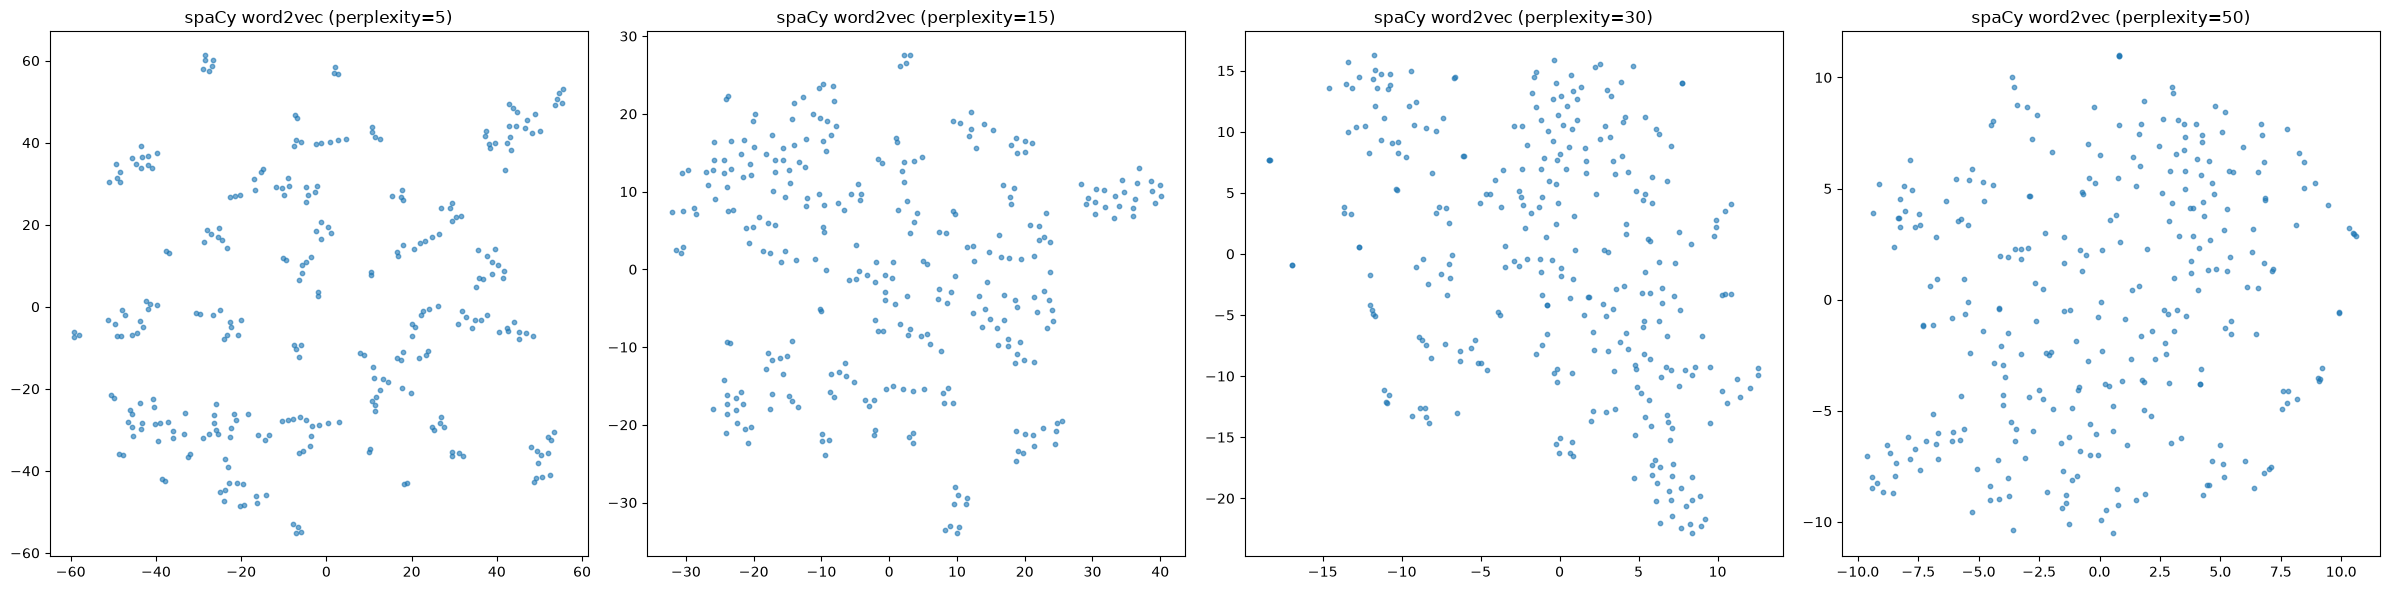

In [23]:
def plot_tsne_perplexities(word2vec_model, perplexities, title_prefix, max_words=300):
    words = list(word2vec_model.wv.index_to_key)[:max_words]
    vectors = np.array([word2vec_model.wv[w] for w in words])

    fig, axes = plt.subplots(1, len(perplexities), figsize=(6 * len(perplexities), 6))
    if len(perplexities) == 1:
        axes = [axes]

    for ax, perp in zip(axes, perplexities):
        tsne = TSNE(
            n_components=2,
            perplexity=min(perp, max(5, len(words) - 1)),
            max_iter=2000,   # renamed from n_iter in scikit-learn 1.5+; n_iter was removed entirely in 1.7
            init='pca',
            random_state=42,
        )
        coords = tsne.fit_transform(vectors)
        ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.6)
        ax.set_title(f"{title_prefix} (perplexity={perp})")

    plt.tight_layout()
    plt.show()

plot_tsne_perplexities(w2v_spacy, perplexities=[5, 15, 30, 50], title_prefix="spaCy word2vec")


**Interpretation prompt (fill in for your slides):** Which perplexity gave the
most stable, interpretable clustering? Do semantically related clinical terms
(e.g. medication names, anatomical terms) end up near each other?


---
## 5. scispaCy

Biomedical-domain NLP. We use a model trained on biomedical text
(`en_core_sci_sm`), which recognizes a broader/more specific set of biomedical
entity types than general spaCy.

**Fallback if you still get a `ConfigValidationError`:** rather than relying only
on the file patch above, we load with an explicit config override that forces the
correct boolean value for the known problem field. This sidesteps a bad value in
the file entirely, regardless of exactly how it's written on disk (quoted,
unquoted, etc).


In [24]:
try:
    nlp_scispacy = spacy.load("en_core_sci_sm")
except Exception as e:
    print(f"Standard load failed ({type(e).__name__}), retrying with a config override...")
    nlp_scispacy = spacy.load(
        "en_core_sci_sm",
        config={"components": {"tok2vec": {"model": {"embed": {"include_static_vectors": False}}}}},
    )

docs_scispacy = list(nlp_scispacy.pipe(df_sample['clean_text'].tolist()))

for ent in docs_scispacy[0].ents:
    print(ent.text, "->", ent.label_)


Standard load failed (ConfigValidationError), retrying with a config override...


ConfigValidationError: 

Config error for 'spacy.MultiHashEmbed.v2'
ner.model.tok2vec.embed -> include_static_vectors	at root: 'False' is not <class 'bool'>
{'@architectures': 'spacy.MultiHashEmbed.v2', 'width': 96, 'attrs': ['NORM', 'PREFIX', 'SUFFIX', 'SHAPE'], 'rows': [5000, 1000, 2500, 2500], 'include_static_vectors': 'False'}

### 5a. Entity extraction across the cohort

In [ ]:
scispacy_entities = []
for doc in docs_scispacy:
    for ent in doc.ents:
        scispacy_entities.append({'text': ent.text, 'label': ent.label_})

df_scispacy_ents = pd.DataFrame(scispacy_entities)
print("Total entities extracted:", len(df_scispacy_ents))
df_scispacy_ents['label'].value_counts()


### 5b. word2vec on the note corpus

In [ ]:
scispacy_sentences = [tokenize(doc) for doc in docs_scispacy]

w2v_scispacy = Word2Vec(
    sentences=scispacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_scispacy.wv))


### 5c. Tuned t-SNE

In [ ]:
plot_tsne_perplexities(w2v_scispacy, perplexities=[5, 15, 30, 50], title_prefix="scispaCy word2vec")


---
## 6. medspaCy

Clinical NLP pipeline with built-in **context detection** — negation, family
history, hypothetical statements — which is where medspaCy differs most from
plain spaCy/scispaCy.

**Why this is the slowest of the three:** medspaCy's `ConText` algorithm checks
every entity against surrounding modifier phrases, so cost scales with both
document length *and* entity count — and MIMIC discharge summaries are the
longest note type (often several thousand words each). Running the full 300-note
sample here with no progress indicator can take a long time and gives zero
feedback while it's working, which just looks frozen. We fix that below by:

1. Using a **smaller subsample just for medspaCy** (adjustable) — the assignment
   only needs enough notes to demonstrate the technique and support a comparison,
   not the full cohort.
2. Adding a **progress bar** (`tqdm`) so you can see it actually working.
3. **Disabling pipeline components you don't need** (e.g. the parser), which are
   the most expensive parts of a spaCy-family pipeline and aren't required for
   entity + context extraction.


In [ ]:
!pip install -q tqdm

In [ ]:
from tqdm.auto import tqdm

# A smaller, medspaCy-specific subsample - increase this once you've confirmed
# timing is acceptable. Discharge summaries are long, so start small.
MEDSPACY_SAMPLE_SIZE = min(75, len(df_sample))
df_medspacy_sample = df_sample.iloc[:MEDSPACY_SAMPLE_SIZE].reset_index(drop=True)
print(f"Running medspaCy on {len(df_medspacy_sample)} notes "
      f"(out of {len(df_sample)} in the full sample used for spaCy/scispaCy)")

nlp_medspacy = medspacy.load(disable=["parser"])  # parser isn't needed for entities/context

docs_medspacy = []
for doc in tqdm(
    nlp_medspacy.pipe(df_medspacy_sample['clean_text'].tolist(), batch_size=5),
    total=len(df_medspacy_sample),
    desc="medspaCy processing notes",
):
    docs_medspacy.append(doc)

for ent in docs_medspacy[0].ents:
    print(ent.text, "-> negated:", ent._.is_negated, "| family:", ent._.is_family, "| hypothetical:", ent._.is_hypothetical)


**If it's still too slow:** lower `MEDSPACY_SAMPLE_SIZE` further (even 20-30
notes is enough to demonstrate negation/family/hypothetical detection with real
examples for your slides), or truncate each note to its first ~2000 characters
before running medspaCy (the History of Present Illness / Hospital Course
sections near the top usually contain plenty of negation examples anyway):

```python
df_medspacy_sample['clean_text'] = df_medspacy_sample['clean_text'].str.slice(0, 2000)
```


### 6a. Visualize context attributes (negation, family history, etc.)

In [ ]:
visualize_ent(docs_medspacy[0])


### 6b. Entity extraction across the cohort (with context attributes)

In [ ]:
medspacy_entities = []
for doc in docs_medspacy:
    for ent in doc.ents:
        medspacy_entities.append({
            'text': ent.text,
            'label': ent.label_,
            'is_negated': ent._.is_negated,
            'is_family': ent._.is_family,
            'is_hypothetical': ent._.is_hypothetical,
        })

df_medspacy_ents = pd.DataFrame(medspacy_entities)
print("Total entities extracted:", len(df_medspacy_ents))
print("\nNegated entities:", df_medspacy_ents['is_negated'].sum())
df_medspacy_ents['label'].value_counts()


### 6c. word2vec on the note corpus

In [ ]:
medspacy_sentences = [tokenize(doc) for doc in docs_medspacy]

w2v_medspacy = Word2Vec(
    sentences=medspacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_medspacy.wv))


### 6d. Tuned t-SNE

In [ ]:
plot_tsne_perplexities(w2v_medspacy, perplexities=[5, 15, 30, 50], title_prefix="medspaCy word2vec")


---
## 7. Compare & Contrast

Summary table of entity counts and unique labels found by each tool.


In [ ]:
comparison = pd.DataFrame({
    'Tool': ['spaCy', 'scispaCy', 'medspaCy'],
    'Total Entities': [len(df_spacy_ents), len(df_scispacy_ents), len(df_medspacy_ents)],
    'Unique Labels': [df_spacy_ents['label'].nunique(), df_scispacy_ents['label'].nunique(), df_medspacy_ents['label'].nunique()],
})
comparison


### Discussion points to write up in your slides

- **Entity coverage:** Which tool found the most clinically relevant entities?
  Did scispaCy/medspaCy catch drug names, diagnoses, or procedures that plain
  spaCy missed?
- **Context awareness:** How many entities did medspaCy flag as negated or
  family-history? Give 2–3 concrete examples (e.g. "**denies** headache" vs
  "patient **has** headache").
- **Embedding structure:** Compare the t-SNE plots — did clinically meaningful
  clusters emerge more clearly for the biomedical-trained models (scispaCy)
  than for general spaCy?
- **Practical tradeoffs:** Speed, ease of setup, and how much post-processing
  each tool needed.


---
## 8. (Bonus) Additional NLP Tool

*Optional +1 point.* Apply an additional tool such as ClinicalBERT, BioBERT, or
BioClinicalBERT to the same note sample and compare its embeddings/entities to
the three above.


In [ ]:
# Example scaffold using a HuggingFace ClinicalBERT model for embeddings
# !pip install -q transformers torch

# from transformers import AutoTokenizer, AutoModel
# import torch

# tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
# model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# def get_cls_embedding(text):
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
#     with torch.no_grad():
#         outputs = model(**inputs)
#     return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# bert_embeddings = np.array([get_cls_embedding(t) for t in df_sample['clean_text'][:50]])
# # Then run the same tuned t-SNE plotting function on these embeddings


---
## 9. Conclusion

*(Fill in after running the notebook)* Summarize which tool performed best for
which purpose, and what you'd recommend for downstream ML feature engineering
using MIMIC notes.
